Outline:
- 
-
-
-


In [588]:
OUTPUT_DIR = '/content/drive/MyDrive/M1_STAGE/Manips/Tables/'     # adapt to your env


#### 1. Generate df of frequencies of interactions for selected frames (transition state)

In [29]:
#SETUP
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from io import StringIO


rootdir = '/content/drive/MyDrive/M1_STAGE/Data/interactions/'
os.chdir(rootdir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
#FUNCTIONS
# a. Open interactions file
def find_hbonds(df):
    hydrogen_bonds = [col for col in df.columns if 'hb' in col]
    return hydrogen_bonds

In [539]:
#MAIN

# 0. Setup 
# 0.1. Load files with interactions
interaction_files = ['res_V12.csv','res_V7.csv']
simulation_names = ['V12', 'V7']

# for all simulations:
# interaction_files = ['res_V1.csv', 'res_V11.csv', 'res_V12.csv', 'res_V7.csv', 'res_V8.csv', 'res_V21.csv']
# simulation_names = ['V1', 'V11', 'V12', 'V7', 'V8', 'V21']

# 0.2. Dictionary to store all calculated frequencies
all_phase_frequencies = {}

# 0.3. Select frames where simulation is in transition between states
selected_frames_dico = {}

# 0.4. Define phase limits
phase_limit_dico = {
    'V7': 198,
    'V8': 180,
    'V21': 155,
    'V12': 35,
    'V11': 1000,
    'V1': 517
}

frame_range_int = 35
for sim in phase_limit_dico:
    phase_limit = phase_limit_dico[sim]
    selected_frames_dico[sim] = range(phase_limit-frame_range_int, phase_limit+frame_range_int+1)

# 0.5. Define the final frequency table column order
phases_list_ordered = ['V12_ph1','V12_ph2','V7_ph1','V7_ph2']

# phases_list_ordered = ['V1_ph1','V1_ph2','V12_ph1','V12_ph2',
#                        'V7_ph1','V7_ph2','V8_ph1','V8_ph2',
#                        'V21_ph1','V21_ph2', 'V11_ph1', 'V11_ph2']

In [541]:
# 1.0. Iterate over interaction files
for i, sim_file in enumerate(interaction_files):
    current_simulation_name = simulation_names[i]

    # 1.1. Create DataFrame for all simulations
    df_full = pd.read_csv(sim_file)

    # 1.2. Get the transition state slice based on selected_frames_dico
    df_trans_state = pd.DataFrame()
    if current_simulation_name in selected_frames_dico:
        frame_range = selected_frames_dico[current_simulation_name]
        df_trans_state = df_full.loc[list(frame_range)]

    # 1.3. Determine phase limit for the current simulation
    phase_limit = phase_limit_dico.get(current_simulation_name)
    # 1.4. Separate into phase 1 and phase 2 DataFrames based on the phase_limit
    ph1_indices = df_trans_state.index[df_trans_state.index <= phase_limit]
    ph2_indices = df_trans_state.index[df_trans_state.index > phase_limit]
    df_ph1 = df_trans_state.loc[ph1_indices] 
    df_ph2 = df_trans_state.loc[ph2_indices]
    n_frames_ph1 = len(df_ph1)
    n_frames_ph2 = len(df_ph2)

    # 1.5. Find all hydrogen bonds in trans df
    all_hbonds_in_trans_state = find_hbonds(df_trans_state)

    # 1.6. Calculate frequencies for Phase 1 of simulation on iteration
    ph1_name = f"{current_simulation_name}_ph1"
    current_ph1_frequencies = {}
    for hbond_col in all_hbonds_in_trans_state:
        if hbond_col in df_ph1.columns and n_frames_ph1 > 0:
            frequency = (df_ph1[hbond_col] > 0).sum() / n_frames_ph1 * 100
        current_ph1_frequencies[hbond_col] = frequency
    all_phase_frequencies[ph1_name] = current_ph1_frequencies

    # 1.7. Calculate frequencies for Phase 2 of simulation on iteration
    ph2_name = f"{current_simulation_name}_ph2"
    current_ph2_frequencies = {}
    for hbond_col in all_hbonds_in_trans_state:
        if hbond_col in df_ph2.columns and n_frames_ph2 > 0:
            frequency = (df_ph2[hbond_col] > 0).sum() / n_frames_ph2 * 100
        current_ph2_frequencies[hbond_col] = frequency
    all_phase_frequencies[ph2_name] = current_ph2_frequencies

In [542]:
    # 6b. Alternatively calculate frequencies for all bonds
        # 6. Calculate frequencies for Phase 1
    # ph1_name = f"{current_simulation_name}_ph1"
    # current_ph1_frequencies = {}
    # for bonds in df_trans_state.columns:
    #     frequency = (df_ph1[bonds] > 0).sum() / n_frames_ph1 * 100
    #     current_ph1_frequencies[bonds] = frequency
    # all_phase_frequencies[ph1_name] = current_ph1_frequencies

    # # 7. Calculate frequencies for Phase 2
    # ph2_name = f"{current_simulation_name}_ph2"
    # current_ph2_frequencies = {}
    # for bonds in df_trans_state.columns:
    #     frequency = (df_ph2[bonds] > 0).sum() / n_frames_ph2 * 100
    #     current_ph2_frequencies[bonds] = frequency
    # all_phase_frequencies[ph2_name] = current_ph2_frequencies

In [543]:
# 2. Save results
# 2.0. Convert the dictionary of dictionaries to a frequency df
# sim_phase = column names, interactions(inner keys) = index
freq_table = pd.DataFrame(all_phase_frequencies) 
freq_table = freq_table[phases_list_ordered]

# 2.2. Filter the df
# remove rows (hbonds) where all frequencies across phases are zero
freq_table = freq_table[freq_table.sum(axis=1) > 0]
filtered_freq_table = freq_table[(freq_table > 80).any(axis=1)]

# 2.3. Save to CSV
output_path = '/content/drive/MyDrive/M1_STAGE/Documents/M1_STAGE/Manips/Tables/interactions_V7_V12.csv'
freq_table.to_csv(output_path, index=True, header=True, decimal=".", float_format="%.5f")


#### 2. Plot Decision tree graph

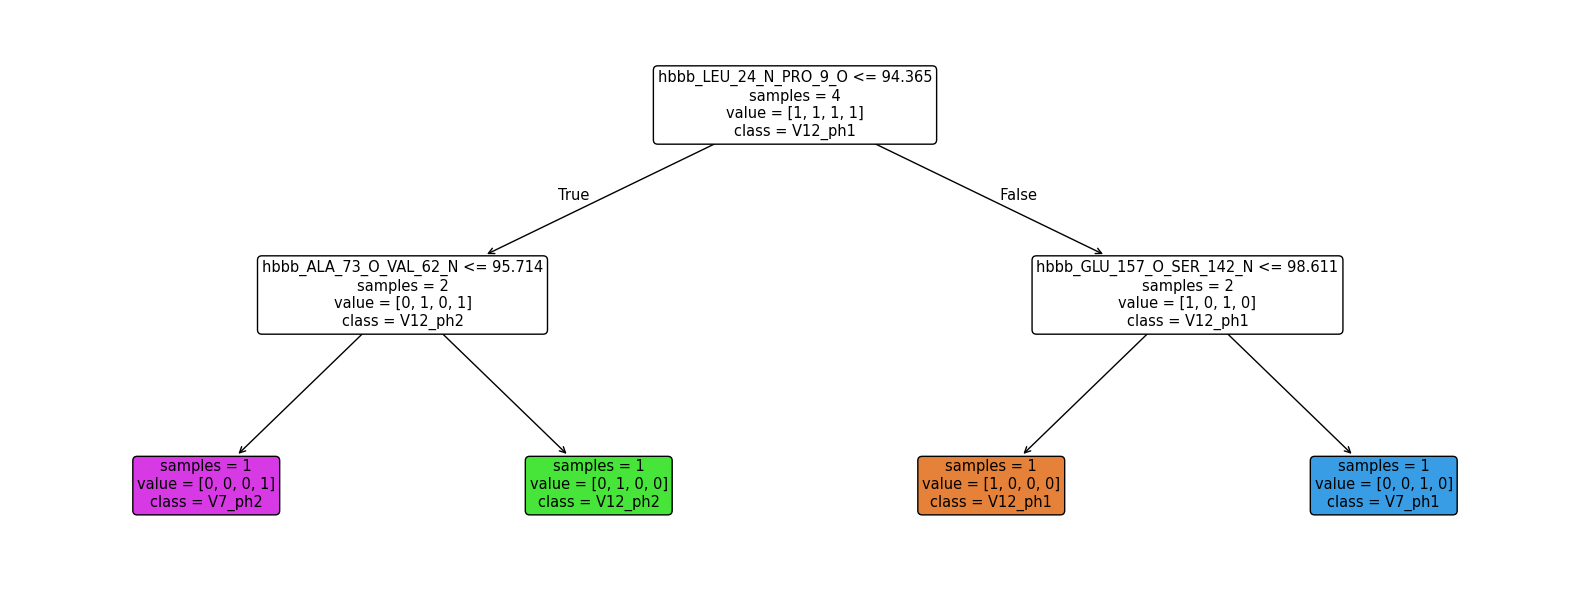

In [552]:
# 1. Transpose df, so that rows = phases, columns = bonds
X = filtered_freq_table.T

# 2. Define the Target: phases
y = X.index

# 3. bonds as feature names
feature_cols = X.columns
#22,989
clf = DecisionTreeClassifier(max_depth=4, random_state=86649)
clf.fit(X, y)

fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(clf, feature_names=feature_cols,
        class_names=y, filled=True, rounded=True,
        impurity=False, proportion=False, ax=ax)

plt.tight_layout()
output_dir = '/content/drive/MyDrive/M1_STAGE/Manips/Figures/'
fig.savefig(os.path.join(output_dir, 'decision_tree.png'), dpi=300, bbox_inches='tight')
plt.show()


### 3. Plot dendrogram (based on frequency) 

Bonds retained after 80% filter: 132


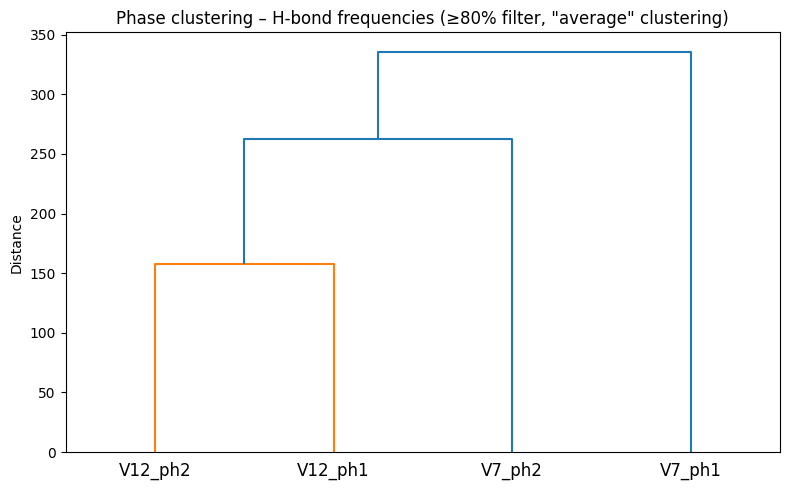

In [562]:
print(f"Bonds retained after 80% filter: {len(filtered_freq_table)}")

X_phases = filtered_freq_table.T     # shape: (n_phases, n_bonds)
y_phases = X_phases.index.tolist()   # phase labels

linked_phases = linkage(X_phases, method='average')

fig, ax = plt.subplots(figsize=(8, 5))
dendrogram(linked_phases, orientation='top', labels=y_phases,
           distance_sort='descending', ax=ax)
ax.set_title('Phase clustering – H-bond frequencies (≥80% filter, "average" clustering)')
ax.set_ylabel('Distance')
plt.tight_layout()
fig.savefig(os.path.join(output_dir, 'dendrogram_phases_raw.png'), dpi=300)
plt.show()

#### 4. Plot dendrogram based on variance

In [583]:
def high_variance_bonds(freq_table: pd.DataFrame,
                        min_delta: float = 20.0,
                        top_n: int | None = None) -> pd.DataFrame:
    sim_names = list({c.rsplit('_', 1)[0] for c in freq_table.columns})
    max_delta = pd.Series(0.0, index=freq_table.index)

    for sim in sim_names:
        ph1 = f"{sim}_ph1"
        ph2 = f"{sim}_ph2"
        if ph1 in freq_table.columns and ph2 in freq_table.columns:
            delta = (freq_table[ph2] - freq_table[ph1]).abs()
            max_delta = max_delta.combine(delta, max)

    mask = max_delta >= min_delta
    result = freq_table[mask]
    if top_n is not None:
        result = result.loc[max_delta[mask].nlargest(top_n).index]
    
    return result

Bonds retained after |Δfreq| ≥ 50% filter: 16


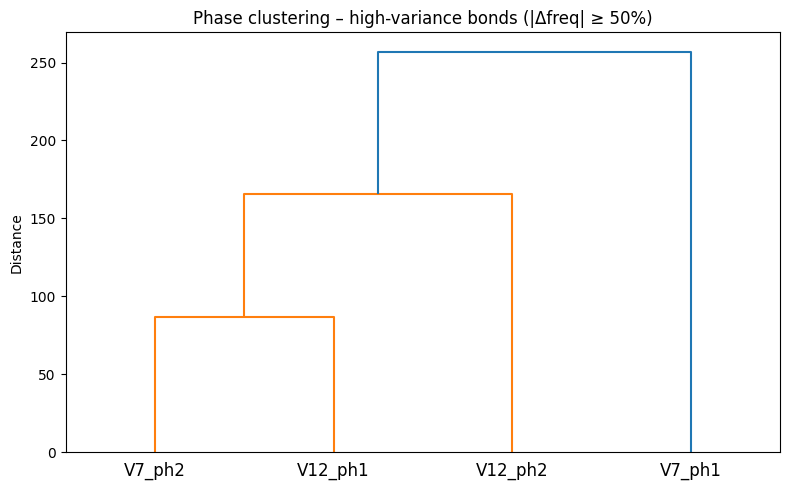

In [585]:
# Only keep bonds that change substantially (|Δfreq| ≥ min_var_percent) between
# ph1 and ph2 in at least one simulation.  This removes bonds that are
# consistently present/absent in both phases and therefore carry no transition
# signal, which was causing V12 vs V7 to dominate the clustering.

min_var_percent = 50

hv_freq = high_variance_bonds(freq_table, min_delta=min_var_percent)
print(f"Bonds retained after |Δfreq| ≥ {min_var_percent}% filter: {len(hv_freq)}")

if len(hv_freq) < 2:
    print("[WARN] Too few high-variance bonds for clustering. Lower min_var_percent.")
else:
    X_phases = hv_freq.T           # (n_phases, n_bonds)
    y_phases = X_phases.index.tolist()

    linked_phases = linkage(X_phases, method='average')
    fig, ax = plt.subplots(figsize=(8, 5))
    dendrogram(linked_phases, orientation='top', labels=y_phases,
            distance_sort='descending', ax=ax)
    ax.set_title(f'Phase clustering – high-variance bonds (|Δfreq| ≥ {min_var_percent}%)')
    ax.set_ylabel('Distance')
    plt.tight_layout()
    fig.savefig(os.path.join(output_dir, 'dendrogram_phases_hv.png'), dpi=300)
    plt.show()

In [ ]:
# --- 5b: Δ-frequency clustering (ph2 − ph1 per simulation) -------------------
# Removes simulation-identity signal entirely; clusters by the *direction* and
# *magnitude* of change.  If V7 and V12 share a common mechanism they should
# cluster together here even if their absolute frequencies differ.

delta_rows = {}
for sim_name in SIMULATION_NAMES:
    ph1_col, ph2_col = f"{sim_name}_ph1", f"{sim_name}_ph2"
    if ph1_col in freq_table.columns and ph2_col in freq_table.columns:
        delta_rows[sim_name] = freq_table[ph2_col] - freq_table[ph1_col]

delta_df = pd.DataFrame(delta_rows).T
delta_df = delta_df.loc[:, (delta_df != 0).any()]

if len(delta_df) >= 2:
    linked_delta = linkage(delta_df, method='ward')
    fig, ax = plt.subplots(figsize=(8, 5))
    dendrogram(linked_delta, orientation='top', labels=delta_df.index.tolist(),
               distance_sort='descending', ax=ax)
    ax.set_title('Simulation clustering – Δ frequency (ph2 − ph1)\n'
                 'Close = similar transition mechanism')
    ax.set_ylabel('Distance')
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'dendrogram_delta_freq.png'), dpi=300)
    plt.show()


In [ ]:

# --- 5c: Cluster BONDS by frequency profile across phases --------------------
# Transpose back so each row is a bond; reveals groups of bonds that change
# together across conditions.

if len(hv_freq) >= 2:
    linked_bonds = linkage(hv_freq, method='ward')
    w = max(10, len(hv_freq) // 3)
    fig, ax = plt.subplots(figsize=(w, 7))
    dendrogram(linked_bonds, orientation='top', labels=hv_freq.index.tolist(),
               distance_sort='descending', leaf_rotation=90, leaf_font_size=7, ax=ax)
    ax.set_title(f'Bond clustering – frequency profile across phases '
                 f'(|Δfreq| ≥ {MIN_DELTA_PCT}%)')
    ax.set_ylabel('Distance')
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'dendrogram_bonds.png'), dpi=300)
    plt.show()

#### 5. PCA  


Explained variance by component:
  PC1: 4.2%  (cumulative: 4.2%)
  PC2: 2.1%  (cumulative: 6.3%)
  PC3: 2.0%  (cumulative: 8.3%)
  PC4: 1.8%  (cumulative: 10.1%)
  PC5: 1.6%  (cumulative: 11.7%)
  PC6: 1.5%  (cumulative: 13.2%)


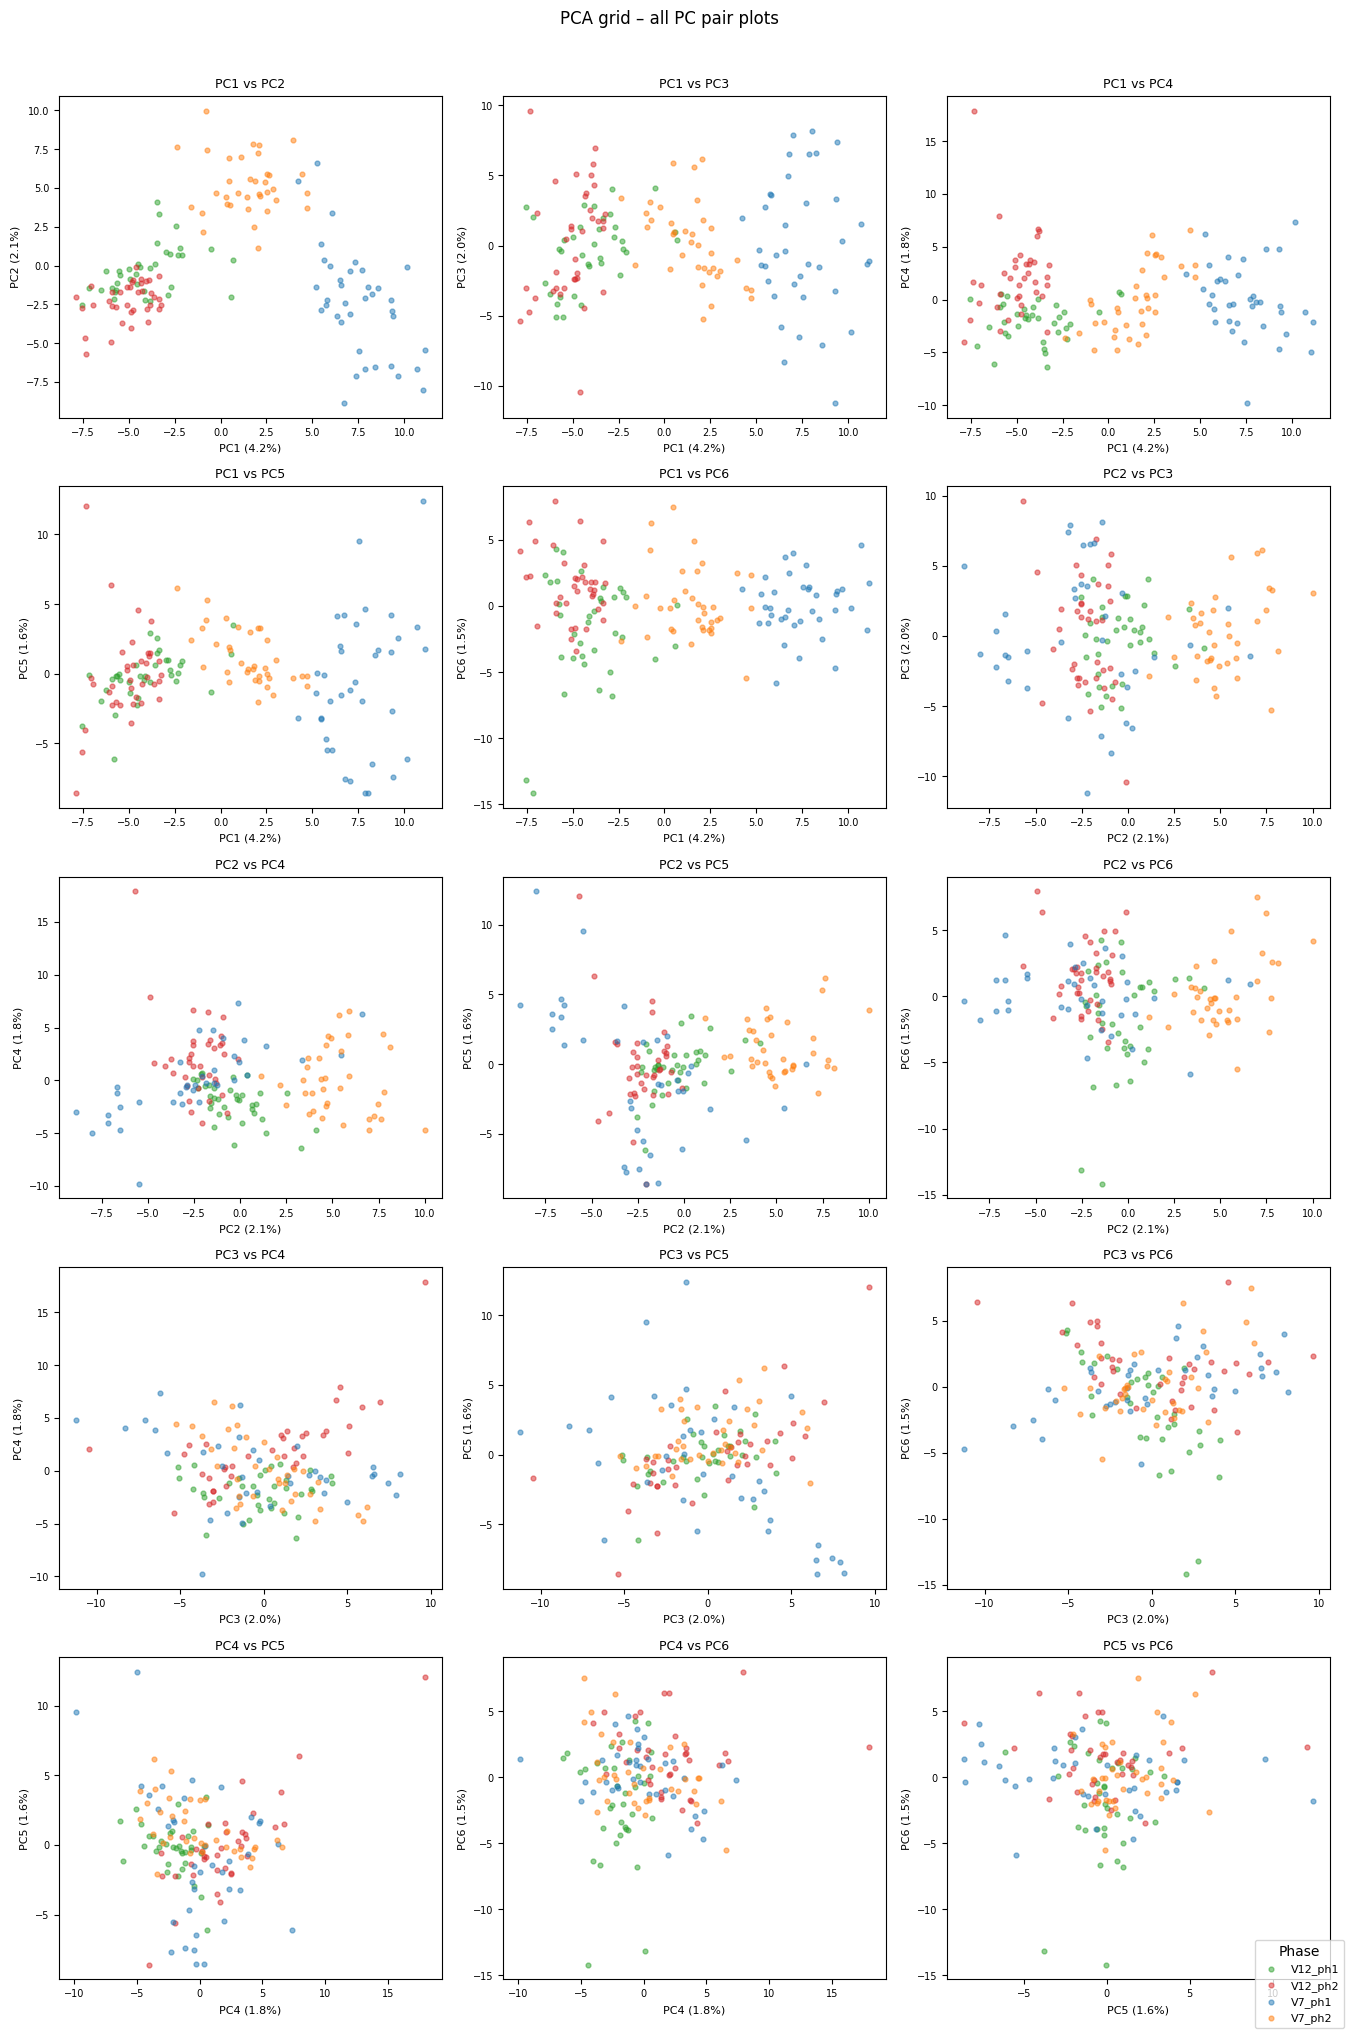

In [589]:
# ── 7: PCA – all PC pairs ─────────────────────────────────────────────────────
# Fit up to N_PCS components, then display every pair (PC1/2, PC1/3, PC2/3 …)
# as a grid of scatter plots.  Higher PCs sometimes capture phase separation
# better than PC1/PC2 when simulation identity dominates the first axes.

N_PCS = 6   # number of principal components to compute; adjust as needed

phase_csv_map = {
    'V7_ph1':  'V7_ph1_interactions.csv',
    'V7_ph2':  'V7_ph2_interactions.csv',
    'V12_ph1': 'V12_ph1_interactions.csv',
    'V12_ph2': 'V12_ph2_interactions.csv',
}

os.chdir(OUTPUT_DIR)

df_pca_input = pd.DataFrame()
for label, fname in phase_csv_map.items():
    if not os.path.exists(fname):
        print(f"[WARN] {fname} not found, skipping for PCA.")
        continue
    df_tmp  = pd.read_csv(fname)
    hb_cols = find_hbonds(df_tmp)
    df_tmp  = df_tmp[hb_cols].copy()
    df_tmp['label'] = label
    df_pca_input = pd.concat([df_pca_input, df_tmp], ignore_index=True)

if not df_pca_input.empty:
    # Clean: drop zero rows and zero columns
    df_pca_input = df_pca_input.loc[
        (df_pca_input.drop('label', axis=1) != 0).any(axis=1)]
    zero_cols = [c for c in df_pca_input.columns
                if c != 'label' and df_pca_input[c].sum() == 0]
    df_pca_input.drop(columns=zero_cols, inplace=True)

    X_pca = df_pca_input.drop('label', axis=1)
    y_pca = df_pca_input['label'].reset_index(drop=True)

    n_components = min(N_PCS, X_pca.shape[1], X_pca.shape[0])
    scaler     = StandardScaler()
    X_scaled   = scaler.fit_transform(X_pca)
    pca        = PCA(n_components=n_components)
    components = pca.fit_transform(X_scaled)
    var_expl   = pca.explained_variance_ratio_ * 100

    pc_cols = [f'PC{i+1}' for i in range(n_components)]
    pca_df  = pd.DataFrame(components, columns=pc_cols)
    pca_df['label']      = y_pca.values
    pca_df['simulation'] = pca_df['label'].str.split('_').str[0]
    pca_df['phase']      = pca_df['label'].str.split('_').str[1]

    print(f"\nExplained variance by component:")
    for i, v in enumerate(var_expl):
        print(f"  PC{i+1}: {v:.1f}%  (cumulative: {var_expl[:i+1].sum():.1f}%)")

    # --- Individual interactive scatter: PC1 vs PC2 (quick reference) ---------
    fig = px.scatter(pca_df, x='PC1', y='PC2', color='label',
                    title=f'PCA – PC1 vs PC2  '
                        f'({var_expl[0]:.1f}% + {var_expl[1]:.1f}%)',
                    labels={'PC1': f'PC1 ({var_expl[0]:.1f}%)',
                            'PC2': f'PC2 ({var_expl[1]:.1f}%)'})
    fig.update_traces(marker=dict(size=6, opacity=0.6))
    fig.write_html(os.path.join(OUTPUT_DIR, 'pca_PC1_PC2.html'))
    fig.show()

    # --- Grid of all PC pair plots (static, saved as PNG) ---------------------
    from itertools import combinations
    pairs = list(combinations(pc_cols, 2))
    ncols = 3
    nrows = -(-len(pairs) // ncols)   # ceiling division

    label_colors = {lbl: c for lbl, c in zip(
        pca_df['label'].unique(),
        plt.cm.tab10.colors[:len(pca_df['label'].unique())])}

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 4.5, nrows * 4),
                            squeeze=False)
    for ax_idx, (pcx, pcy) in enumerate(pairs):
        row, col = divmod(ax_idx, ncols)
        ax = axes[row][col]
        for lbl, grp in pca_df.groupby('label'):
            ax.scatter(grp[pcx], grp[pcy],
                    label=lbl, s=12, alpha=0.5,
                    color=label_colors[lbl])
        xi, yi = int(pcx[2:]) - 1, int(pcy[2:]) - 1
        ax.set_xlabel(f'{pcx} ({var_expl[xi]:.1f}%)', fontsize=8)
        ax.set_ylabel(f'{pcy} ({var_expl[yi]:.1f}%)', fontsize=8)
        ax.set_title(f'{pcx} vs {pcy}', fontsize=9)
        ax.tick_params(labelsize=7)

    # Hide unused axes
    for ax_idx in range(len(pairs), nrows * ncols):
        row, col = divmod(ax_idx, ncols)
        axes[row][col].set_visible(False)

    # Single shared legend
    handles, labels_leg = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc='lower right',
            fontsize=8, title='Phase', framealpha=0.8)
    fig.suptitle('PCA grid – all PC pair plots', fontsize=12, y=1.01)
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'pca_grid.png'), dpi=300,
                bbox_inches='tight')
    plt.show()

    # --- Per-PC interactive plots (coloured by phase only, for clarity) --------
    for pcx, pcy in [(f'PC{i}', f'PC{i+1}') for i in range(1, n_components)]:
        xi, yi = int(pcx[2:]) - 1, int(pcy[2:]) - 1
        fig_i = px.scatter(pca_df, x=pcx, y=pcy, color='label',
                        symbol='simulation',
                        title=f'PCA – {pcx} vs {pcy}  '
                            f'({var_expl[xi]:.1f}% + {var_expl[yi]:.1f}%)',
                        labels={pcx: f'{pcx} ({var_expl[xi]:.1f}%)',
                                pcy: f'{pcy} ({var_expl[yi]:.1f}%)'})
        fig_i.update_traces(marker=dict(size=6, opacity=0.6))
        fig_i.write_html(os.path.join(OUTPUT_DIR, f'pca_{pcx}_{pcy}.html'))
        fig_i.show()

else:
    print("[INFO] No phase CSVs found; PCA skipped.")

#### 7. Inter-chain analysis

In [ ]:
# ── 6: Inter-chain interaction analysis ───────────────────────────────────────
# Chain A: residues 1–99 | Chain B: residues 100–198
# We separate all bonds into intra-A, intra-B, and inter-chain (A↔B),
# then compare their frequencies across phases.

print("\n─── Inter-chain interaction analysis ───")

interchain_mask = pd.Series(
    {bond: is_interchain(bond) for bond in freq_table.index}
)
intraA_mask = pd.Series({
    bond: (classify_chain(get_residue_numbers(bond)[0]) == 'A' and
           classify_chain(get_residue_numbers(bond)[1]) == 'A')
    for bond in freq_table.index
})
intraB_mask = pd.Series({
    bond: (classify_chain(get_residue_numbers(bond)[0]) == 'B' and
           classify_chain(get_residue_numbers(bond)[1]) == 'B')
    for bond in freq_table.index
})

freq_interchain = freq_table[interchain_mask]
freq_intraA     = freq_table[intraA_mask]
freq_intraB     = freq_table[intraB_mask]

print(f"  Intra-chain A bonds : {len(freq_intraA)}")
print(f"  Intra-chain B bonds : {len(freq_intraB)}")
print(f"  Inter-chain A↔B    : {len(freq_interchain)}")

# Save inter-chain table
freq_interchain.to_csv(os.path.join(OUTPUT_DIR, 'freq_interchain.csv'),
                       index=True, decimal='.', float_format='%.5f')

# Heatmap of inter-chain bonds across phases
if not freq_interchain.empty:
    # Apply same high-variance filter so the heatmap stays readable
    ic_hv = high_variance_bonds(freq_interchain, min_delta=MIN_DELTA_PCT)
    if ic_hv.empty:
        ic_hv = freq_interchain   # fall back to all if nothing passes the filter

    fig, ax = plt.subplots(figsize=(max(6, len(ic_hv.columns) * 1.5),
                                    max(4, len(ic_hv) * 0.4)))
    sns.heatmap(ic_hv, annot=True, fmt='.0f', cmap='Blues',
                linewidths=0.3, cbar_kws={'label': 'Frequency (%)'}, ax=ax)
    ax.set_title('Inter-chain (A↔B) H-bond frequencies across phases')
    ax.set_xlabel('Phase')
    ax.set_ylabel('Bond')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'heatmap_interchain.png'), dpi=300,
                bbox_inches='tight')
    plt.show()

    # Δ-frequency bar chart: which inter-chain bonds change most at the transition?
    delta_ic = {}
    for sim_name in SIMULATION_NAMES:
        ph1_col, ph2_col = f"{sim_name}_ph1", f"{sim_name}_ph2"
        if ph1_col in ic_hv.columns and ph2_col in ic_hv.columns:
            delta_ic[sim_name] = ic_hv[ph2_col] - ic_hv[ph1_col]

    if delta_ic:
        delta_ic_df = pd.DataFrame(delta_ic)
        delta_ic_df['mean_delta'] = delta_ic_df.mean(axis=1)
        delta_ic_df = delta_ic_df.sort_values('mean_delta')

        fig, ax = plt.subplots(figsize=(8, max(4, len(delta_ic_df) * 0.4)))
        colors = ['#d73027' if v < 0 else '#1a9850' for v in delta_ic_df['mean_delta']]
        ax.barh(delta_ic_df.index, delta_ic_df['mean_delta'], color=colors)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Mean Δ frequency ph2 − ph1 (%)')
        ax.set_title('Inter-chain bond changes at the ph1→ph2 transition\n'
                     'Green = gained, Red = lost')
        plt.tight_layout()
        fig.savefig(os.path.join(OUTPUT_DIR, 'delta_interchain.png'), dpi=300,
                    bbox_inches='tight')
        plt.show()
else:
    print("[INFO] No inter-chain bonds detected. Check residue numbering in column names.")

#### 8. 

In [ ]:
# ── 8: Decision Tree ──────────────────────────────────────────────────────────
# Fit on the aggregated frequency table (phases as samples, bonds as features)
# to find the bonds that best discriminate between sim-phases.

X_dt = X_phases                       # (n_phases, n_bonds)
y_dt = y_phases                       # phase labels

clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_dt, y_dt)

fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(clf, feature_names=X_phases.columns.tolist(),
          class_names=y_dt, filled=True, rounded=True,
          impurity=False, proportion=False, ax=ax)
ax.set_title('Decision Tree – discriminating bonds between sim-phases')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'decision_tree.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\nMost discriminating features (top 10 by importance):")
importances = pd.Series(clf.feature_importances_, index=X_phases.columns)
print(importances.sort_values(ascending=False).head(10))